In [46]:
import numpy as np
from PIL import Image
from copy import copy
from typing import Tuple

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

np.set_printoptions(precision=2, suppress=True, floatmode='fixed')

## Детектор Канни

In [47]:
def calculate_sigma(size: int) -> float:
    """Вычисляет sigma на основе размера ядра, как в OpenCV."""
    return 0.3 * ((size - 1) * 0.5 - 1) + 0.8

In [48]:
def auto_canny(image: np.ndarray, sigma: float = 0.33) -> Tuple[float, float]:
    """Вычисляет low_threshold и high_threshold"""
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return lower, upper

In [49]:
def gaussian_kernel(size: int, sigma: float = 1) -> np.ndarray:
    """Создает гауссово ядро заданного размера."""
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    kernel = np.exp(-((x**2 + y**2) / (2.0 * sigma**2))) * normal
    return kernel / np.sum(kernel) 

In [50]:
def convolve(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Свертка изображения с ядром."""
    kernel_size = kernel.shape[0]
    pad_size = kernel_size // 2
    padded_image = np.pad(image, pad_size, mode='constant')
    output = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            output[i, j] = np.sum(padded_image[i:i+kernel_size, j:j+kernel_size] * kernel)
            
    return output

In [51]:
def sobel_filters(image: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Применение оператора Собеля для вычисления градиентов."""
    kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    kernel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)

    gradient_x = convolve(image, kernel_x)
    gradient_y = convolve(image, kernel_y)

    gradient_magnitude = np.hypot(gradient_x, gradient_y)
    gradient_direction = np.arctan2(gradient_y, gradient_x)

    return gradient_magnitude, gradient_direction

In [52]:
def non_max_suppression(gradient_magnitude: np.ndarray, gradient_direction: np.ndarray) -> np.ndarray:
    """Подавление немаксимумов."""
    suppressed = np.zeros_like(gradient_magnitude)
    angle = gradient_direction * 180 / np.pi
    angle[angle < 0] += 180

    for i in range(1, gradient_magnitude.shape[0] - 1):
        for j in range(1, gradient_magnitude.shape[1] - 1):
            q = 255
            r = 255

            # Угол 0
            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = gradient_magnitude[i, j + 1]
                r = gradient_magnitude[i, j - 1]
            # Угол 45
            elif (22.5 <= angle[i, j] < 67.5):
                q = gradient_magnitude[i + 1, j - 1]
                r = gradient_magnitude[i - 1, j + 1]
            # Угол 90
            elif (67.5 <= angle[i, j] < 112.5):
                q = gradient_magnitude[i + 1, j]
                r = gradient_magnitude[i - 1, j]
            # Угол 135
            elif (112.5 <= angle[i, j] < 157.5):
                q = gradient_magnitude[i - 1, j - 1]
                r = gradient_magnitude[i + 1, j + 1]

            if (gradient_magnitude[i, j] >= q) and (gradient_magnitude[i, j] >= r):
                suppressed[i, j] = gradient_magnitude[i, j]
            else:
                suppressed[i, j] = 0

    return suppressed

In [53]:
def double_threshold(suppressed: np.ndarray, low_threshold: float, high_threshold: float) -> np.ndarray:
    """Двойная пороговая фильтрация."""
    edges = np.zeros_like(suppressed)
    strong = suppressed > high_threshold
    weak = (suppressed >= low_threshold) & (suppressed <= high_threshold)

    edges[strong] = 255
    edges[weak] = 100

    return edges

In [54]:
def hysteresis(edges: np.ndarray) -> np.ndarray:
    """Трассировка контуров с гистерезисом."""
    for i in range(1, edges.shape[0] - 1):
        for j in range(1, edges.shape[1] - 1):
            if edges[i, j] == 100:
                if (edges[i + 1, j - 1] == 255 or edges[i + 1, j] == 255 or edges[i + 1, j + 1] == 255 or
                    edges[i, j - 1] == 255 or edges[i, j + 1] == 255 or
                    edges[i - 1, j - 1] == 255 or edges[i - 1, j] == 255 or edges[i - 1, j + 1] == 255):
                    edges[i, j] = 255
                else:
                    edges[i, j] = 0
    return edges


In [55]:
def canny_edge_detector(image_path: np.ndarray, ksize: int = 5, low_threshold: float = 50, high_threshold: float = 150) -> np.ndarray:
    """Применение детектора Канни для изображения"""
    # Чтение изображения и преобразование в grayscale
    image = Image.open(image_path).convert("L")
    image_array = np.array(image, dtype=np.float32)
    sigma = calculate_sigma(ksize)

    # 1. Сглаживание изображения с помощью гауссова фильтра
    kernel = gaussian_kernel(size=ksize, sigma=sigma)
    smoothed = convolve(image_array, kernel)

    # 2. Вычисление градиентов с помощью оператора Собеля
    gradient_magnitude, gradient_direction = sobel_filters(smoothed) 

    # 3. Подавление не-максимумов
    suppressed = non_max_suppression(gradient_magnitude, gradient_direction)

    # 4. Двойная пороговая фильтрация
    edges = double_threshold(suppressed, low_threshold, high_threshold)

    # 5. Трассировка контуров с гистерезисом
    edges = hysteresis(edges)

    return edges

In [56]:
def morphological_closing(image: np.ndarray, kernel_size: int = 7) -> np.ndarray:
    """Морфологическая операция замыкания"""
    def dilate(image, kernel):
        M, N = image.shape
        output = np.zeros_like(image)
        pad = kernel_size // 2
        image_padded = np.pad(image, pad, mode='constant')
        for i in range(M):
            for j in range(N):
                output[i, j] = np.max(image_padded[i:i+kernel_size, j:j+kernel_size] * kernel)
        return output

    def erode(image, kernel):
        M, N = image.shape
        output = np.zeros_like(image)
        pad = kernel_size // 2
        image_padded = np.pad(image, pad, mode='constant')
        for i in range(M):
            for j in range(N):
                output[i, j] = np.min(image_padded[i:i+kernel_size, j:j+kernel_size] * kernel)
        return output

    kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)
    dilated = dilate(image, kernel)
    closed = erode(dilated, kernel)
    return closed

## Кластеризация

In [57]:
def calculate_perimeter(image_name: str, ksize: int = 5, low_threshold: float = 50, high_threshold: float = 150) -> int:
    """Вычисление периметра фигуры"""
    image_path = f"origins/task_1/{image_name}.jpg"
    image_path_save = f"results/task_1/{image_name}_det_kanny.png"

    edges = canny_edge_detector(image_path, ksize, low_threshold, high_threshold)

    # closed_edges = morphological_closing(edges)

    Image.fromarray(edges.astype(np.uint8)).save(image_path_save)

    edges = edges / 255.0

    return np.sum(edges)
            

In [58]:
def calculate_area(image_name: str, color_threshold: float = 0) -> int:
    """Вычисление площади фигуры"""
    image_path = f"origins/task_1/{image_name}.jpg"

    image = Image.open(image_path).convert("L")
    image_array = np.array(image, dtype=np.float32)

    width, height = image.size

    area = sum(1 for x in range(width) for y in range(height) if image_array[y, x] > color_threshold)
    
    return area

In [59]:
def calculate_average_color(image_name: str) -> int:
    """Вычисление среднего значение цвета"""
    image_path = f"origins/task_1/{image_name}.jpg"

    image = Image.open(image_path).convert("L")
    image_array = np.array(image, dtype=np.float32)

    return image_array.mean()


In [60]:
def calculate_fig_params(image_name: str, color_threshold: float = 0, ksize: int = 5, low_threshold: float = 50, high_threshold: float = 150) -> Tuple[int, int, float]:
    """Вычисление параметров фигуры: площадь, периметр, среднее значение цвета"""
    return (calculate_area(image_name, color_threshold), 
            calculate_perimeter(image_name, ksize, low_threshold, high_threshold),
            calculate_average_color(image_name))

## Инициализация параметров фигур

In [61]:
# 1) Наличие окружности
# 2) Наличие треугольника
# 3) Колличество углов
# 4) Площадь фигуры
# 5) Периметр фигуры / периметр контура
# 6) Цвет
# 7) Число контуров
# 8) Симметричность

figures_names = np.array(["треугольник", "овал", "солнце", "смайл", "тучка"])

figures = np.array([
    [0, 1, 3, *calculate_fig_params("triangle", ksize = 5, low_threshold = 50, high_threshold = 150), 1, 0], # треугольник
    [1, 0, 0, *calculate_fig_params("circle", ksize = 5, low_threshold = 50, high_threshold = 150), 1, 1], # овал
    [1, 1, 24, *calculate_fig_params("sun", ksize = 1, low_threshold = 50, high_threshold = 200), 9, 1], # солнце
    [1, 0, 0, *calculate_fig_params("smile", ksize = 3, low_threshold = 50, high_threshold = 100), 4, 0], # смайл
    [1, 0, 0, *calculate_fig_params("cloud", ksize = 3, low_threshold = 30, high_threshold = 50), 4, 0]  # тучка
])

In [62]:
print(figures)

[[    0.00     1.00     3.00 46384.00  1512.00   236.98     1.00     0.00]
 [    1.00     0.00     0.00 14520.00   411.00   137.68     1.00     1.00]
 [    1.00     1.00    24.00 35256.00  1374.00   207.58     9.00     1.00]
 [    1.00     0.00     0.00 24603.00  1324.00   166.37     4.00     0.00]
 [    1.00     0.00     0.00 37536.00  1616.00   168.38     4.00     0.00]]


# Агломмеративная кластеризация

In [63]:
def euclidean_distance(a: float, b: float) -> float:
    """Вычисления евклидова расстояния"""
    return np.sqrt(np.sum((a - b) ** 2))

In [64]:
def compute_distance_matrix(data: np.ndarray) -> np.ndarray:
    """Вычисления матрицы расстояний"""
    n = data.shape[0]
    distance_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            distance_matrix[i, j] = euclidean_distance(data[i], data[j])
            distance_matrix[j, i] = distance_matrix[i, j]
            
    return distance_matrix

In [65]:
def agglomerative_clustering(data: np.ndarray, n_clusters: int) -> Tuple[list, list]:
    """Аггломеративной кластеризация"""
    n = data.shape[0]
    clusters = [[i] for i in range(n)]
    distance_matrix = compute_distance_matrix(data)
    history = [] 
    
    while len(clusters) > n_clusters:
        # Находим два ближайших кластера
        min_distance = np.inf
        cluster1, cluster2 = -1, -1

        # Вычисляем расстояние между кластерами как среднее расстояние между их элементами
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                distance = 0
                count = 0
                for x in clusters[i]:
                    for y in clusters[j]:
                        distance += distance_matrix[x, y]
                        count += 1
                distance /= count

                if distance < min_distance:
                    min_distance = distance
                    cluster1, cluster2 = i, j

        # Сохраняем историю объединения
        history.append((copy(clusters[cluster1]), copy(clusters[cluster2]), min_distance))

        # Объединяем два ближайших кластера
        clusters[cluster1].extend(clusters[cluster2])
        clusters.pop(cluster2)

    return clusters, history

In [66]:
clusters, history = agglomerative_clustering(figures, n_clusters=2)

In [67]:
# Выводим историю объединения
for step, (cluster1, cluster2, distance) in enumerate(history):
    print(f"Шаг {step + 1}: Объединение {cluster1} и {cluster2} на расстоянии {distance:.2f}")

Шаг 1: Объединение [2] и [4] на расстоянии 2293.27
Шаг 2: Объединение [0] и [2, 4] на расстоянии 9988.90
Шаг 3: Объединение [1] и [3] на расстоянии 10124.29


In [68]:
# Выводим результат

for i, cluster in enumerate(clusters):
    print(f"Кластер {i + 1}: {cluster}")

    elements_names = []

    print(figures_names[cluster])

Кластер 1: [0, 2, 4]
['треугольник' 'солнце' 'тучка']
Кластер 2: [1, 3]
['овал' 'смайл']


# Дендрограмма

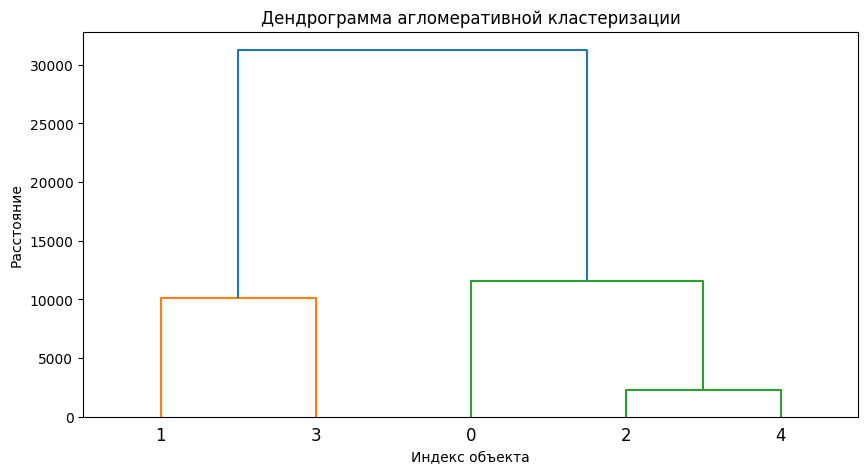

In [69]:
# Вычисляем матрицу связей для дендрограммы
Z = linkage(figures, method='ward')

# Отрисовываем дендрограмму
plt.figure(figsize=(10, 5))
plt.title("Дендрограмма агломеративной кластеризации")
plt.xlabel("Индекс объекта")
plt.ylabel("Расстояние")
dendrogram(Z)
plt.show()

## Дивизивная кластеризация

In [70]:
def compute_variance(cluster: np.ndarray) -> float:
    """Функция для вычисления внутрикластерной дисперсии"""
    if len(cluster) == 0:
        return 0

    centroid = np.mean(cluster, axis=0)

    return np.sum((cluster - centroid) ** 2)

In [71]:
### Шаг 2. Разделение кластера на 2 части (аналог K-means с K=2)
def split_cluster(cluster: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Разделение кластера на 2 части"""
    if len(cluster) <= 1:
        return cluster, None  # Нельзя разделить
    
    # Инициализируем центроиды случайными точками
    idx = np.random.choice(len(cluster), 2, replace=False)
    centroids = cluster[idx]
    
    # Итеративно обновляем центроиды
    for _ in range(10):  # Простенький K-means (можно улучшить)
        distances = np.array([
            np.sum((cluster - centroids[0]) ** 2, axis=1),
            np.sum((cluster - centroids[1]) ** 2, axis=1)
        ])
        labels = np.argmin(distances, axis=0)
        
        new_centroids = [
            np.mean(cluster[labels == 0], axis=0),
            np.mean(cluster[labels == 1], axis=0)
        ]
        
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    
    # Возвращаем два подкластера
    cluster1 = cluster[labels == 0]
    cluster2 = cluster[labels == 1]
    
    return cluster1, cluster2

In [72]:
def divisive_clustering(data: np.ndarray, n_clusters: int) -> np.ndarray:
    """Дивизивной кластеризации"""
    clusters = [data.copy()]
    
    while len(clusters) < n_clusters:
        # Находим кластер с максимальной дисперсией
        variances = [compute_variance(c) for c in clusters]
        idx_max_var = np.argmax(variances)
        cluster_to_split = clusters.pop(idx_max_var)
        
        # Делим его на два
        cluster1, cluster2 = split_cluster(cluster_to_split)
        
        if cluster2 is not None: 
            clusters.append(cluster1)
            clusters.append(cluster2)
        else:
            clusters.append(cluster1) 
    
    return clusters

In [73]:
n_clusters = 3
final_clusters = divisive_clustering(figures, n_clusters)

In [74]:
# Результат
for i, cluster in enumerate(final_clusters):
    print(f"Кластер {i + 1}:")

    clust_inds = []
    for point in cluster:
        print(f"  {point}")
        for ind, j in enumerate(figures):
            if np.array_equal(j, point):
                clust_inds.append(ind)

    print(figures_names[clust_inds])

Кластер 1:
  [    1.00     0.00     0.00 14520.00   411.00   137.68     1.00     1.00]
  [    1.00     0.00     0.00 24603.00  1324.00   166.37     4.00     0.00]
['овал' 'смайл']
Кластер 2:
  [    1.00     1.00    24.00 35256.00  1374.00   207.58     9.00     1.00]
  [    1.00     0.00     0.00 37536.00  1616.00   168.38     4.00     0.00]
['солнце' 'тучка']
Кластер 3:
  [    0.00     1.00     3.00 46384.00  1512.00   236.98     1.00     0.00]
['треугольник']


## K-means

In [75]:
def initialize_centroids(data: np.ndarray, k: int) -> np.ndarray:
    """Инициализации центроидов"""
    indices = np.random.choice(len(data), k, replace=False)
    return data[indices]

In [76]:
def assign_clusters(data: np.ndarray, centroids: np.ndarray) -> int:
    """Назначение точек ближайшим центроидам"""
    distances = np.sqrt(((data[:, np.newaxis] - centroids) ** 2).sum(axis=2))
    return np.argmin(distances, axis=1)

In [77]:
def update_centroids(data: np.ndarray, labels: np.ndarray, k: int) -> np.ndarray:
    """Обновление центроидов"""
    new_centroids = np.zeros((k, data.shape[1]))

    for i in range(k):
        cluster_points = data[labels == i]
        if len(cluster_points) > 0:
            new_centroids[i] = cluster_points.mean(axis=0)
            
    return new_centroids

In [78]:
def kmeans(data: np.ndarray, k: int, max_iter: int = 100) -> Tuple[np.ndarray, np.ndarray]:
    """Алгоритм K-means"""
    centroids = initialize_centroids(data, k)
    
    for _ in range(max_iter):
        labels = assign_clusters(data, centroids)
        new_centroids = update_centroids(data, labels, k)
        
        # Проверяем сходимость (центроиды не изменились)
        if np.allclose(centroids, new_centroids):
            break
        
        centroids = new_centroids
    
    return labels, centroids

In [79]:
k = 2

labels, centroids = kmeans(figures, k)

In [80]:
# Результаты
for i in range(k):
    cluster_points = figures[labels == i]
    indexes = np.where(labels == i)[0] 
    
    print(f"Кластер {i + 1} (центроид: {centroids[i]}):")
    for point in cluster_points:
        print(f"  {point}")

    print(figures_names[indexes], "\n")

Кластер 1 (центроид: [    1.00     0.00     0.00 19561.50   867.50   152.03     2.50     0.50]):
  [    1.00     0.00     0.00 14520.00   411.00   137.68     1.00     1.00]
  [    1.00     0.00     0.00 24603.00  1324.00   166.37     4.00     0.00]
['овал' 'смайл'] 

Кластер 2 (центроид: [    0.67     0.67     9.00 39725.33  1500.67   204.31     4.67     0.33]):
  [    0.00     1.00     3.00 46384.00  1512.00   236.98     1.00     0.00]
  [    1.00     1.00    24.00 35256.00  1374.00   207.58     9.00     1.00]
  [    1.00     0.00     0.00 37536.00  1616.00   168.38     4.00     0.00]
['треугольник' 'солнце' 'тучка'] 



## С-means

In [81]:
def initialize_membership(n_samples: int, n_clusters: int) -> np.ndarray:
    """Инициализация матрицы принадлежностей (случайная)"""
    U = np.random.rand(n_samples, n_clusters)
    
    return U / U.sum(axis=1, keepdims=True)  # Нормализация (сумма по строке = 1)

In [82]:
def update_centroids(data: np.ndarray, U: np.ndarray, m: float) -> np.ndarray:
    """Обновление центроидов (с учетом степеней принадлежности)"""
    n_clusters = U.shape[1]
    centroids = np.zeros((n_clusters, data.shape[1]))

    for j in range(n_clusters):
        U_j = U[:, j] ** m
        centroids[j] = np.sum(U_j[:, np.newaxis] * data, axis=0) / np.sum(U_j)
        
    return centroids

In [83]:
def update_membership(data: np.ndarray, centroids: np.ndarray, m: float) -> np.ndarray:
    """Обновление матрицы принадлежностей"""
    n_samples = data.shape[0]
    n_clusters = centroids.shape[0]
    U_new = np.zeros((n_samples, n_clusters))
    
    for i in range(n_samples):
        for j in range(n_clusters):
            # Вычисляем расстояние от точки i до центроида j
            dist_ij = np.sqrt(np.sum((data[i] - centroids[j]) ** 2))

            # Если точка совпадает с центроидом, присваиваем 1
            if dist_ij == 0:
                U_new[i, j] = 1.0
            else:
                # Сумма отношений расстояний
                sum_terms = 0.0
                for k in range(n_clusters):
                    dist_ik = np.sqrt(np.sum((data[i] - centroids[k]) ** 2))
                    sum_terms += (dist_ij / dist_ik) ** (2 / (m - 1))
                    
                U_new[i, j] = 1.0 / sum_terms
                
    return U_new

In [84]:
def fuzzy_c_means(data: np.ndarray, n_clusters: int = 2, m: float = 2.0, max_iter: int = 100, tol: float = 1e-5) -> Tuple[np.ndarray, np.ndarray]:
    """Алгоритм Fuzzy C-means"""
    n_samples = data.shape[0]
    U = initialize_membership(n_samples, n_clusters)
    
    for _ in range(max_iter):
        centroids = update_centroids(data, U, m)
        U_new = update_membership(data, centroids, m)
        
        # Проверяем сходимость (изменение в U меньше порога)
        if np.max(np.abs(U_new - U)) < tol:
            break
        
        U = U_new
    
    return U, centroids

In [85]:
n_clusters = 2
fuzziness = 2.0  # Параметр нечеткости (m > 1)

In [86]:
U, centroids = fuzzy_c_means(figures, n_clusters, m=fuzziness)

In [87]:
# Результаты
print("Центроиды кластеров:")
for j, centroid in enumerate(centroids):
    print(f"Кластер {j + 1}: {centroid}")

Центроиды кластеров:
Кластер 1: [    0.68     0.64     8.56 39600.56  1503.93   202.92     4.61     0.32]
Кластер 2: [    1.00     0.00     0.07 19222.68   830.70   151.11     2.38     0.54]


In [88]:
print("Степени принадлежности точек к кластерам:")
for i, (point, membership) in enumerate(zip(figures, U)):
    print(f"Фигура {i + 1} ({figures_names[i]}): {point}")
    
    for j in range(n_clusters):
        print(f"  Кластер {j + 1}: {membership[j]:.4f}")

    print("\n")

Степени принадлежности точек к кластерам:
Фигура 1 (треугольник): [    0.00     1.00     3.00 46384.00  1512.00   236.98     1.00     0.00]
  Кластер 1: 0.9413
  Кластер 2: 0.0587


Фигура 2 (овал): [    1.00     0.00     0.00 14520.00   411.00   137.68     1.00     1.00]
  Кластер 1: 0.0342
  Кластер 2: 0.9658


Фигура 3 (солнце): [    1.00     1.00    24.00 35256.00  1374.00   207.58     9.00     1.00]
  Кластер 1: 0.9316
  Кластер 2: 0.0684


Фигура 4 (смайл): [    1.00     0.00     0.00 24603.00  1324.00   166.37     4.00     0.00]
  Кластер 1: 0.1148
  Кластер 2: 0.8852


Фигура 5 (тучка): [    1.00     0.00     0.00 37536.00  1616.00   168.38     4.00     0.00]
  Кластер 1: 0.9874
  Кластер 2: 0.0126


